# <font color='#FFE15D'>**Diamond Price Prediction**</font>

|Column Name|Description|
|-----------|-----------|
|carat|The weight of the diamond, measured in carats. A higher carat value means a heavier diamond|
|cut|Refers to how well the diamond has been cut from its raw form. Categories can range from ‘Ideal’ (best) to ‘Fair’ (worst)|
|color|A measure of how colorless the diamond is. This is graded from ‘D’ (colorless) to ‘J’ (light yellow or brown)|
|clarity|Refers to the absence of inclusions and blemishes. ‘IF’ means Internally Flawless, indicating no inclusions and only blemishes are visible to a skilled grader. ‘I1’ means inclusions are obvious under 10x magnification and can affect transparency and brilliance|
|x|Length in mm|
|y|Width in mm|
|z|Depth in mm|
|depth|Total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)|
|table|Width of top of diamond relative to widest point (43--95)|
|price|Price in US dollars (326--18,823)|

## 🔸 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  missingno as msno
import seaborn as sns

## 🔸 Load Dataset

In [2]:
df = pd.read_csv('diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Getting information about the dataset

In [3]:
df.shape

(50000, 10)

In [4]:
df.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.799444,61.753006,57.457830,3944.805440,5.734403,5.737956,3.541056
std,0.475173,1.431088,2.232092,3997.938105,1.123077,1.145579,0.707065
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Getting the unique values of categorical features

In [6]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Column: {column}")
        print(df[column].unique())

Column: cut
['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
Column: color
['E' 'I' 'J' 'H' 'F' 'G' 'D']
Column: clarity
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


## **🔸 Exploratory Data Analysis (EDA)**

### Single Variable Analysis

### Carat

Plotting histogram for feature 'carat' to get a good understaning of how many carats the majority of diamonds in the df have

<Axes: xlabel='carat', ylabel='Count'>

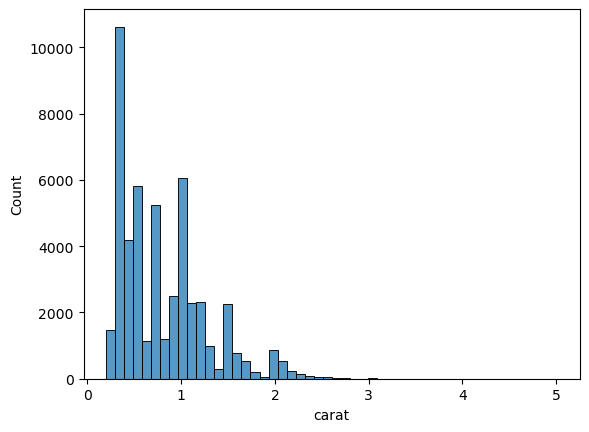

In [7]:
sns.histplot(x='carat', data=df, bins=50)

### Cuts and Colors

Using pie plot to see how the different types of cuts are distributed among the various diamonds in df and what color the diamonds in the dataset have

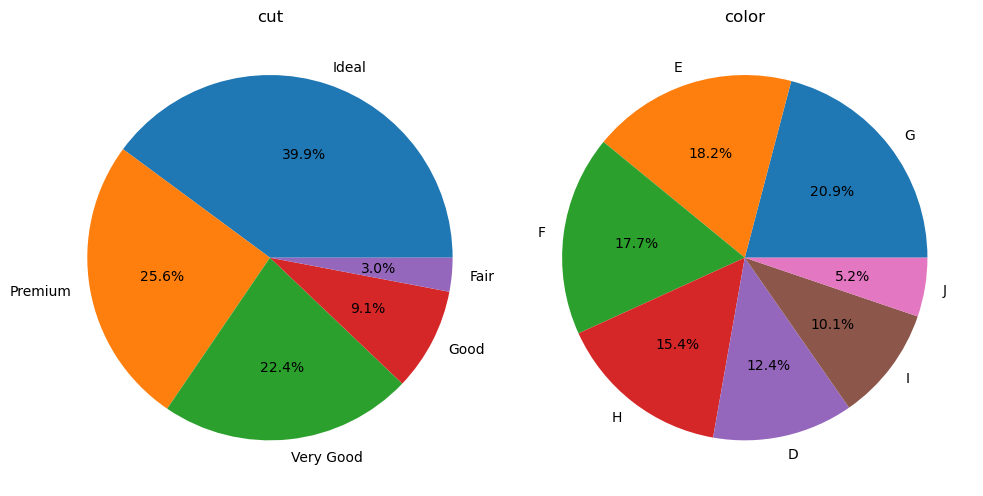

In [8]:
cols = ['cut', 'color']

fig, axes = plt.subplots(1, len(cols), figsize=(10, 5))

for i, col in enumerate(cols):
    values = df[col].value_counts()
    axes[i].pie(values, labels=values.index, autopct='%1.1f%%')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Clarity

<Axes: xlabel='clarity', ylabel='count'>

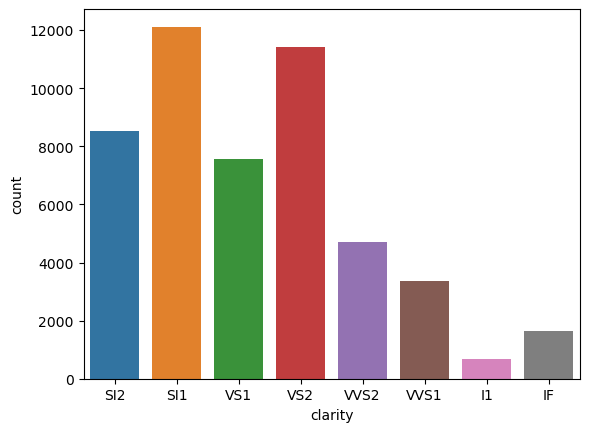

In [9]:
sns.countplot(x='clarity', data=df)

### Two Variable Analysis

### Cut, Color and Clarity vs Price

**Cut**:
   - The "Ideal" category has the highest frequency, followed by "Very Good" and "Premium." The "Fair" category has the lowest frequency.

**Color**:
   - The second bar plot represents the color quality of diamonds. It also has five categories: "D," "E," "F," "G," and "H."
   - The "G" category seems to be the most common, while "D" and "E" are less frequent.

**Clarity**:
   - The third bar plot shows the clarity of diamonds. It includes categories like "IF" (Internally Flawless), "VVS1" (Very, Very Slightly Included 1), "VS1" (Very Slightly Included 1), and others.
   - The "VS1" category appears to be the most prevalent, followed by "SI1" (Slightly Included 1).

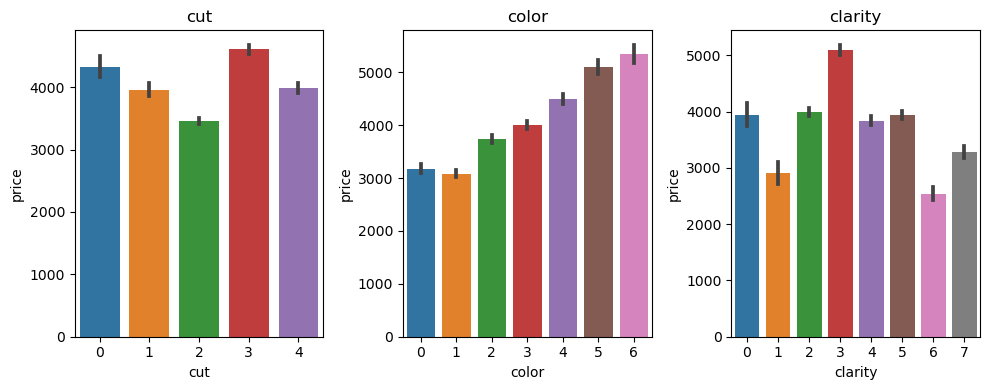

In [31]:
cols = ['cut', 'color', 'clarity']

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for i, col in enumerate(cols):
    ax = axes[i]
    sns.barplot(x=col, y='price', data=df, ax=ax)
    ax.set_title(col)
    
plt.tight_layout()
plt.show()

### Carat, X, Y and Z vs Price

As carat weight increases, the price tends to increase as well. This positive correlation suggests that larger diamonds are generally more expensive.

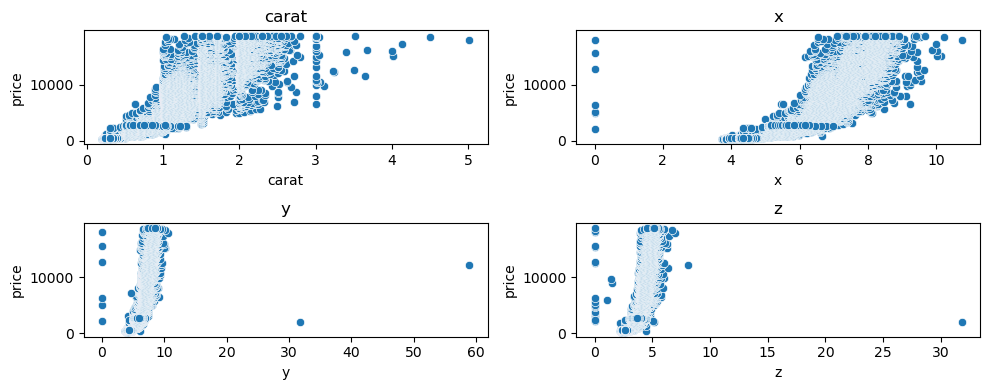

In [36]:
cols = ['carat', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 2, figsize=(10, 4))

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    sns.scatterplot(x=col, y='price', data=df, ax=ax)
    ax.set_title(col)
    
plt.tight_layout()
plt.show()

## **🔸 Data Preprocessing**

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
cols = df.columns[df.dtypes == 'object']

le = LabelEncoder()

for col in cols:
    le.fit(df[col])
    df[col] = le.transform(df[col])

In [14]:
df.dtypes

carat      float64
cut          int32
color        int32
clarity      int32
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

### Confusion Matrix

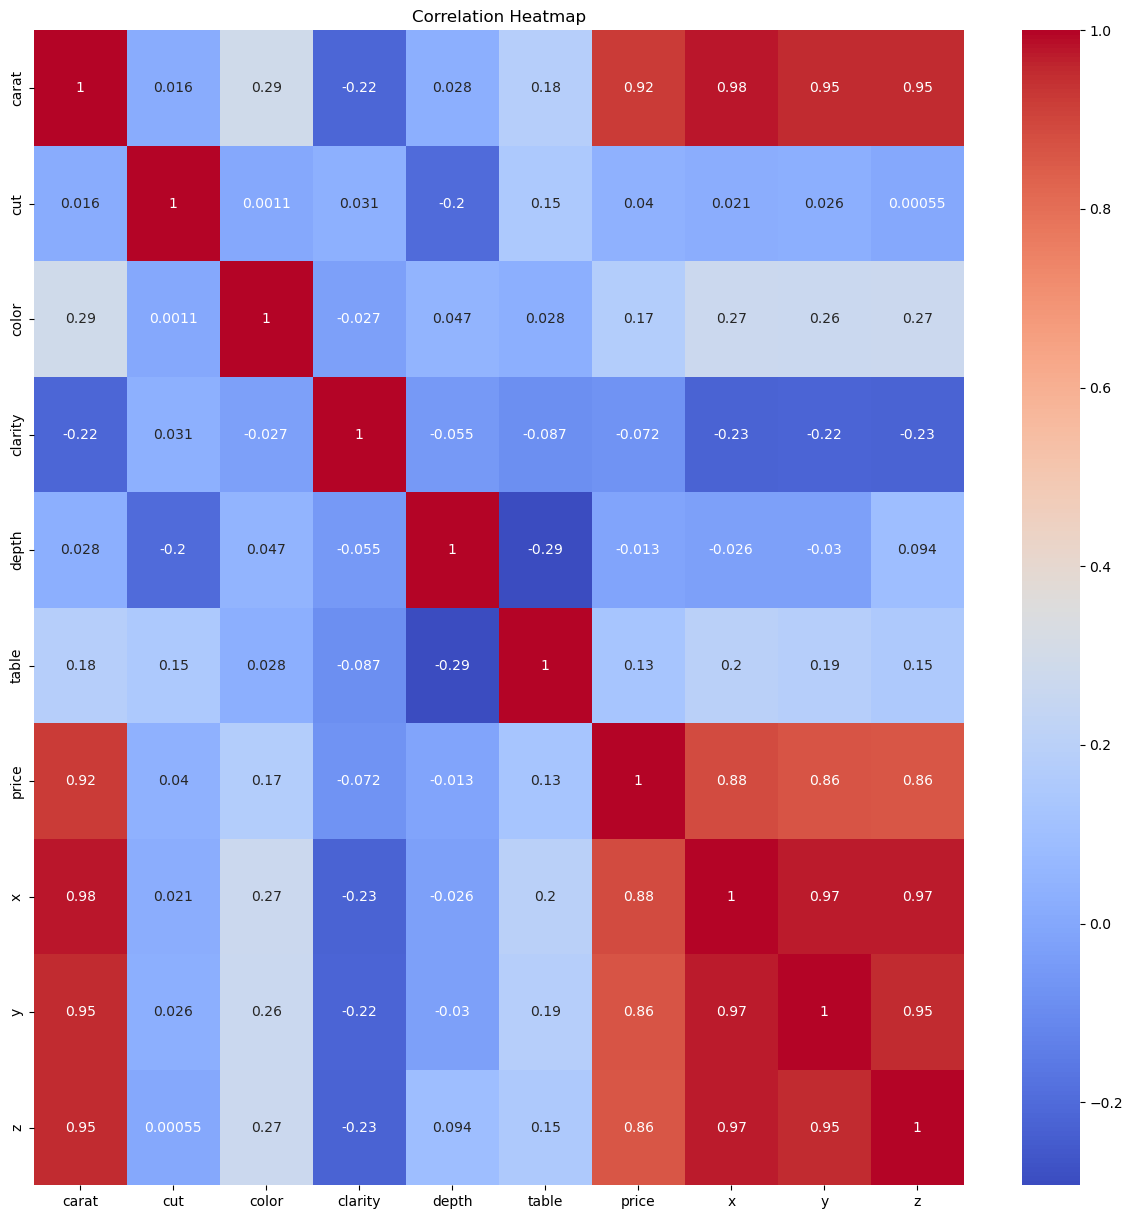

In [15]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
y = df['price']
X = df.drop(columns='price')

In [18]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **🔸 Model Training**

In [19]:
from sklearn.tree import *
from sklearn.ensemble import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier

### Decision Tree

In [20]:
dtree = DecisionTreeRegressor(max_depth=4, random_state=42, ccp_alpha=0.001)

In [21]:
dtree.fit(x_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.001, max_depth=4, random_state=42)

In [22]:
d_pred = dtree.predict(x_test)
print('Training Accuracy: ', dtree.score(x_train, y_train))

Training Accuracy:  0.9067267851814101


### Random Forest

In [23]:
rfr = RandomForestRegressor(max_depth=4, random_state=42, ccp_alpha=0.001)

In [24]:
rfr.fit(x_train, y_train)

RandomForestRegressor(ccp_alpha=0.001, max_depth=4, random_state=42)

In [25]:
rfr_pred = rfr.predict(x_test)
print('Training Accuracy: ', rfr.score(x_train, y_train))

Training Accuracy:  0.9142371609663562


## **🔸 Evaluation**

In [26]:
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, f1_score

### Distribution Plot

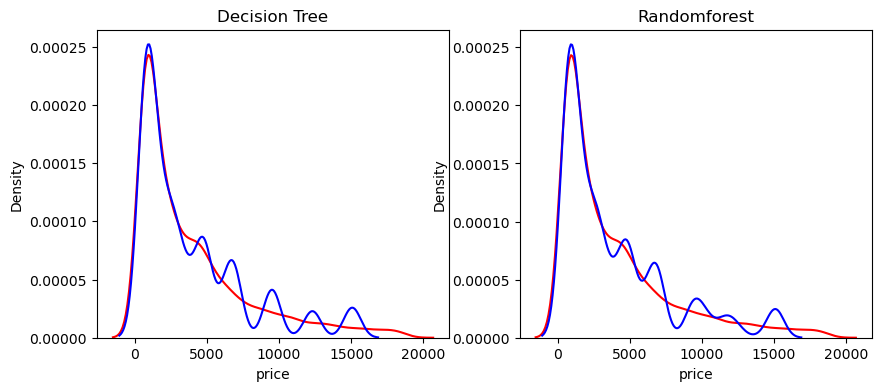

In [27]:
models = {'Decision Tree' : d_pred, 'Randomforest': rfr_pred}
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for i, model_name in enumerate(models):
    sns.kdeplot(y_test, color='r', label="Actual Value", ax=ax[i]).set_title(model_name)
    sns.kdeplot(models[model_name], color='b', label="Fitted Values" , ax=ax[i])